In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml


harvey = pd.read_csv("/home/bri/pymol/EDA/static/harvey_outputs/scores_df_extended_with_chai.csv")
YAML_PATH =  Path("/home/bri/pymol/EDA/static/metric_directions.yaml")
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/rankings")
OUTPUT_DIR.mkdir(exist_ok=True)


print(f"harvey:\n{harvey['binder'].value_counts()}")


harvey.describe()

harvey:
binder
0    29
1    27
Name: count, dtype: int64


,binder,EC50[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,af3_iplddt,af3_ipsae,af3_pdockq,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm
count,56.000000,1.000000e+00,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,...,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,0.482143,2.100000e-07,13.535497,75.268429,393.054107,13.607500,13.635439,68.732392,0.284559,0.242412,...,2.282055,0.875394,0.702436,0.533550,0.429961,0.531114,0.811567,0.823852,0.374025,0.536052
std,0.504203,NaN,2.054006,2.282659,230.678258,7.156542,5.435418,7.445870,0.216728,0.120188,...,0.677953,0.041935,0.083643,0.108039,0.146105,0.069326,0.034103,0.033621,0.154196,0.112840
min,0.000000,2.100000e-07,10.399938,71.030357,77.770000,2.870000,5.747656,54.736793,0.000000,0.065700,...,0.649316,0.782540,0.537988,0.178800,0.130400,0.332800,0.736590,0.728108,0.118825,0.187032
25%,0.000000,2.100000e-07,12.059449,73.236611,229.080000,8.007500,9.557901,63.187184,0.107832,0.155650,...,1.882490,0.844775,0.650773,0.495850,0.309875,0.482550,0.785464,0.809087,0.253314,0.478951
50%,0.000000,2.100000e-07,12.828443,75.146750,347.195000,11.765000,12.111968,66.786747,0.253416,0.213400,...,2.216903,0.878891,0.710634,0.552250,0.429750,0.542250,0.817100,0.829140,0.391051,0.556627
75%,1.000000,2.100000e-07,15.252550,77.107626,520.772500,17.737500,17.137083,72.721877,0.461964,0.312725,...,2.738912,0.902508,0.757540,0.613200,0.525250,0.585075,0.840146,0.844928,0.478884,0.603073
max,1.000000,2.100000e-07,18.475244,79.729492,1209.770000,35.170000,27.103704,84.903689,0.686851,0.538000,...,4.002924,0.961794,0.871298,0.682700,0.794900,0.684200,0.866754,0.899859,0.698466,0.759819


In [2]:
cols_to_drop=(['af3_rank', 'af3_ranking_score', 'af3_rank0_masif', 'cf_rank', 'cf_rank0_masif']) #, 'af3_pdockq', 'cf_pdockq', 'chai_unconstrained_pdockq', 'chai_constrained_pdockq', 'boltz_free_pdockq', 'boltz_template_pdockq', 'chai_constrained_per_chain_ptm', 'chai_constrained_interface_iptm', 'chai_unconstrained_interface_iptm', 'chai_constrained_per_chain_iptm', 'chai_unconstrained_per_chain_iptm', 'chai_unconstrained_per_chain_ptm'])  #  

scores_df = harvey.drop(columns=cols_to_drop)

# vllt drop 'KD[M]', 'EC50[M]' too?
#scores_df.head()

### data transformation

In [3]:
exclude_cols = ['KD[M]', 'EC50[M]']  # columns to exclude
numeric_cols = scores_df.select_dtypes(include=['number']).columns.tolist()

# Remove excluded columns from numeric_cols
for col in exclude_cols:
    if col in numeric_cols:
        numeric_cols.remove(col)
    

# Remove binder
if 'binder' in numeric_cols:
    numeric_cols.remove('binder')

numeric_cols
len(numeric_cols)  

80

In [4]:
# Group metrics by model (?)

models = ['af3', 'cf', 'esmfold', 'chai_constrained', 'chai_unconstrained', 'boltz_free', 'boltz_template']
model_groups = {model: [c for c in numeric_cols if c.startswith(model)] for model in models}

metric_families = {
    "plddt": [
        "af3_plddt",
        "cf_plddt",
        "esmfold_plddt",
        "boltz_free_plddt",
        "boltz_template_plddt",
    ],

    "ptm": [
        "af3_ptm",
        "cf_ptm",
        "esmfold_ptm",
        "chai_unconstrained_ptm",
        "chai_constrained_ptm",
        "boltz_free_ptm",
        "boltz_template_ptm",
    ],

    "iptm": [
        "af3_iptm",
        "cf_iptm",
        "chai_unconstrained_iptm",
        "chai_constrained_iptm",
        "boltz_free_iptm",
        "boltz_template_iptm",
    ],

    "pdockq2": [
        "af3_pdockq2",
        "cf_pdockq2",
        "chai_unconstrained_pdockq2",
        "chai_constrained_pdockq2",
        "boltz_free_pdockq2",
        "boltz_template_pdockq2",
    ],
}


In [5]:

# Create the 3-group logic to be able to distuinguish between easy and hard negatives
def categorize_row(row):
    if row['binder'] == 1:
        return 'Binder'
    elif row['type'] == 'original': # binder = 0
        return 'Non-Binder'
    else: # binder = 0 and type = target_shuffle
        return 'Target Shuffle'

scores_df['binder_type'] = scores_df.apply(categorize_row, axis=1)

# Map the colors explicitly to the groups
colors_map = {
    'Binder': '#2ecc71',      # Green
    'Non-Binder': "#67e7dd",  # Aquamarine
    'Target Shuffle': "#273397",       # Blue
    'germinal': "#2ecc71",
    'mcmahon': "#d6a439",
    'snir_ab': "#1f3397",
    'harvey': "#971f91"
}

In [6]:
scores_df.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm,binder_type
0,harvey,original,1,NaN,NaN,AT118i4h32_AGTR1,11.528240,78.049861,241.77,7.91,...,0.953019,0.871298,0.5023,0.5615,0.6842,0.796724,0.899859,0.419045,0.759819,Binder
1,harvey,original,1,NaN,NaN,AT201_AGTR1,12.212700,76.021409,108.25,7.19,...,0.910365,0.755096,0.4618,0.3734,0.5413,0.781721,0.829062,0.118825,0.567248,Binder
2,harvey,original,1,NaN,NaN,AT202_AGTR1,13.119915,76.458147,299.89,11.87,...,0.822987,0.587241,0.6138,0.2044,0.4111,0.783286,0.839246,0.179008,0.542771,Binder
3,harvey,original,1,NaN,NaN,AT203_AGTR1,11.603302,78.053494,77.77,2.87,...,0.910428,0.795326,0.6598,0.6871,0.5950,0.804622,0.812353,0.337474,0.616371,Binder
4,harvey,original,1,NaN,NaN,AT204_AGTR1,16.662872,71.692176,456.19,24.69,...,0.815329,0.557721,0.5336,0.2333,0.4120,0.799096,0.822275,0.142731,0.556965,Binder


In [7]:
# read metric_directions.yaml (directionality should be +1 for metrics where higher is better, -1 for metrics where lower is better, applied after scaling)

if Path(YAML_PATH).exists():
    with open(YAML_PATH, 'r') as f:
        yaml_data = yaml.safe_load(f)
    
    # Extract directions
    raw_directions = {k: v['direction'] for k, v in yaml_data['metrics'].items()}
    metric_directions = dict(sorted(raw_directions.items(), key=lambda x: len(x[0]), reverse=True))
    print(f"Loaded {len(metric_directions)} metric directions from YAML.")
else:
    print(f"WARNING: YAML not found at {YAML_PATH}. Using default direction (+1).")
    metric_directions = {}

def get_direction(col_name):
    for base_metric, direction in metric_directions.items():
        if base_metric in col_name: 
            return direction
    return 1

Loaded 88 metric directions from YAML.


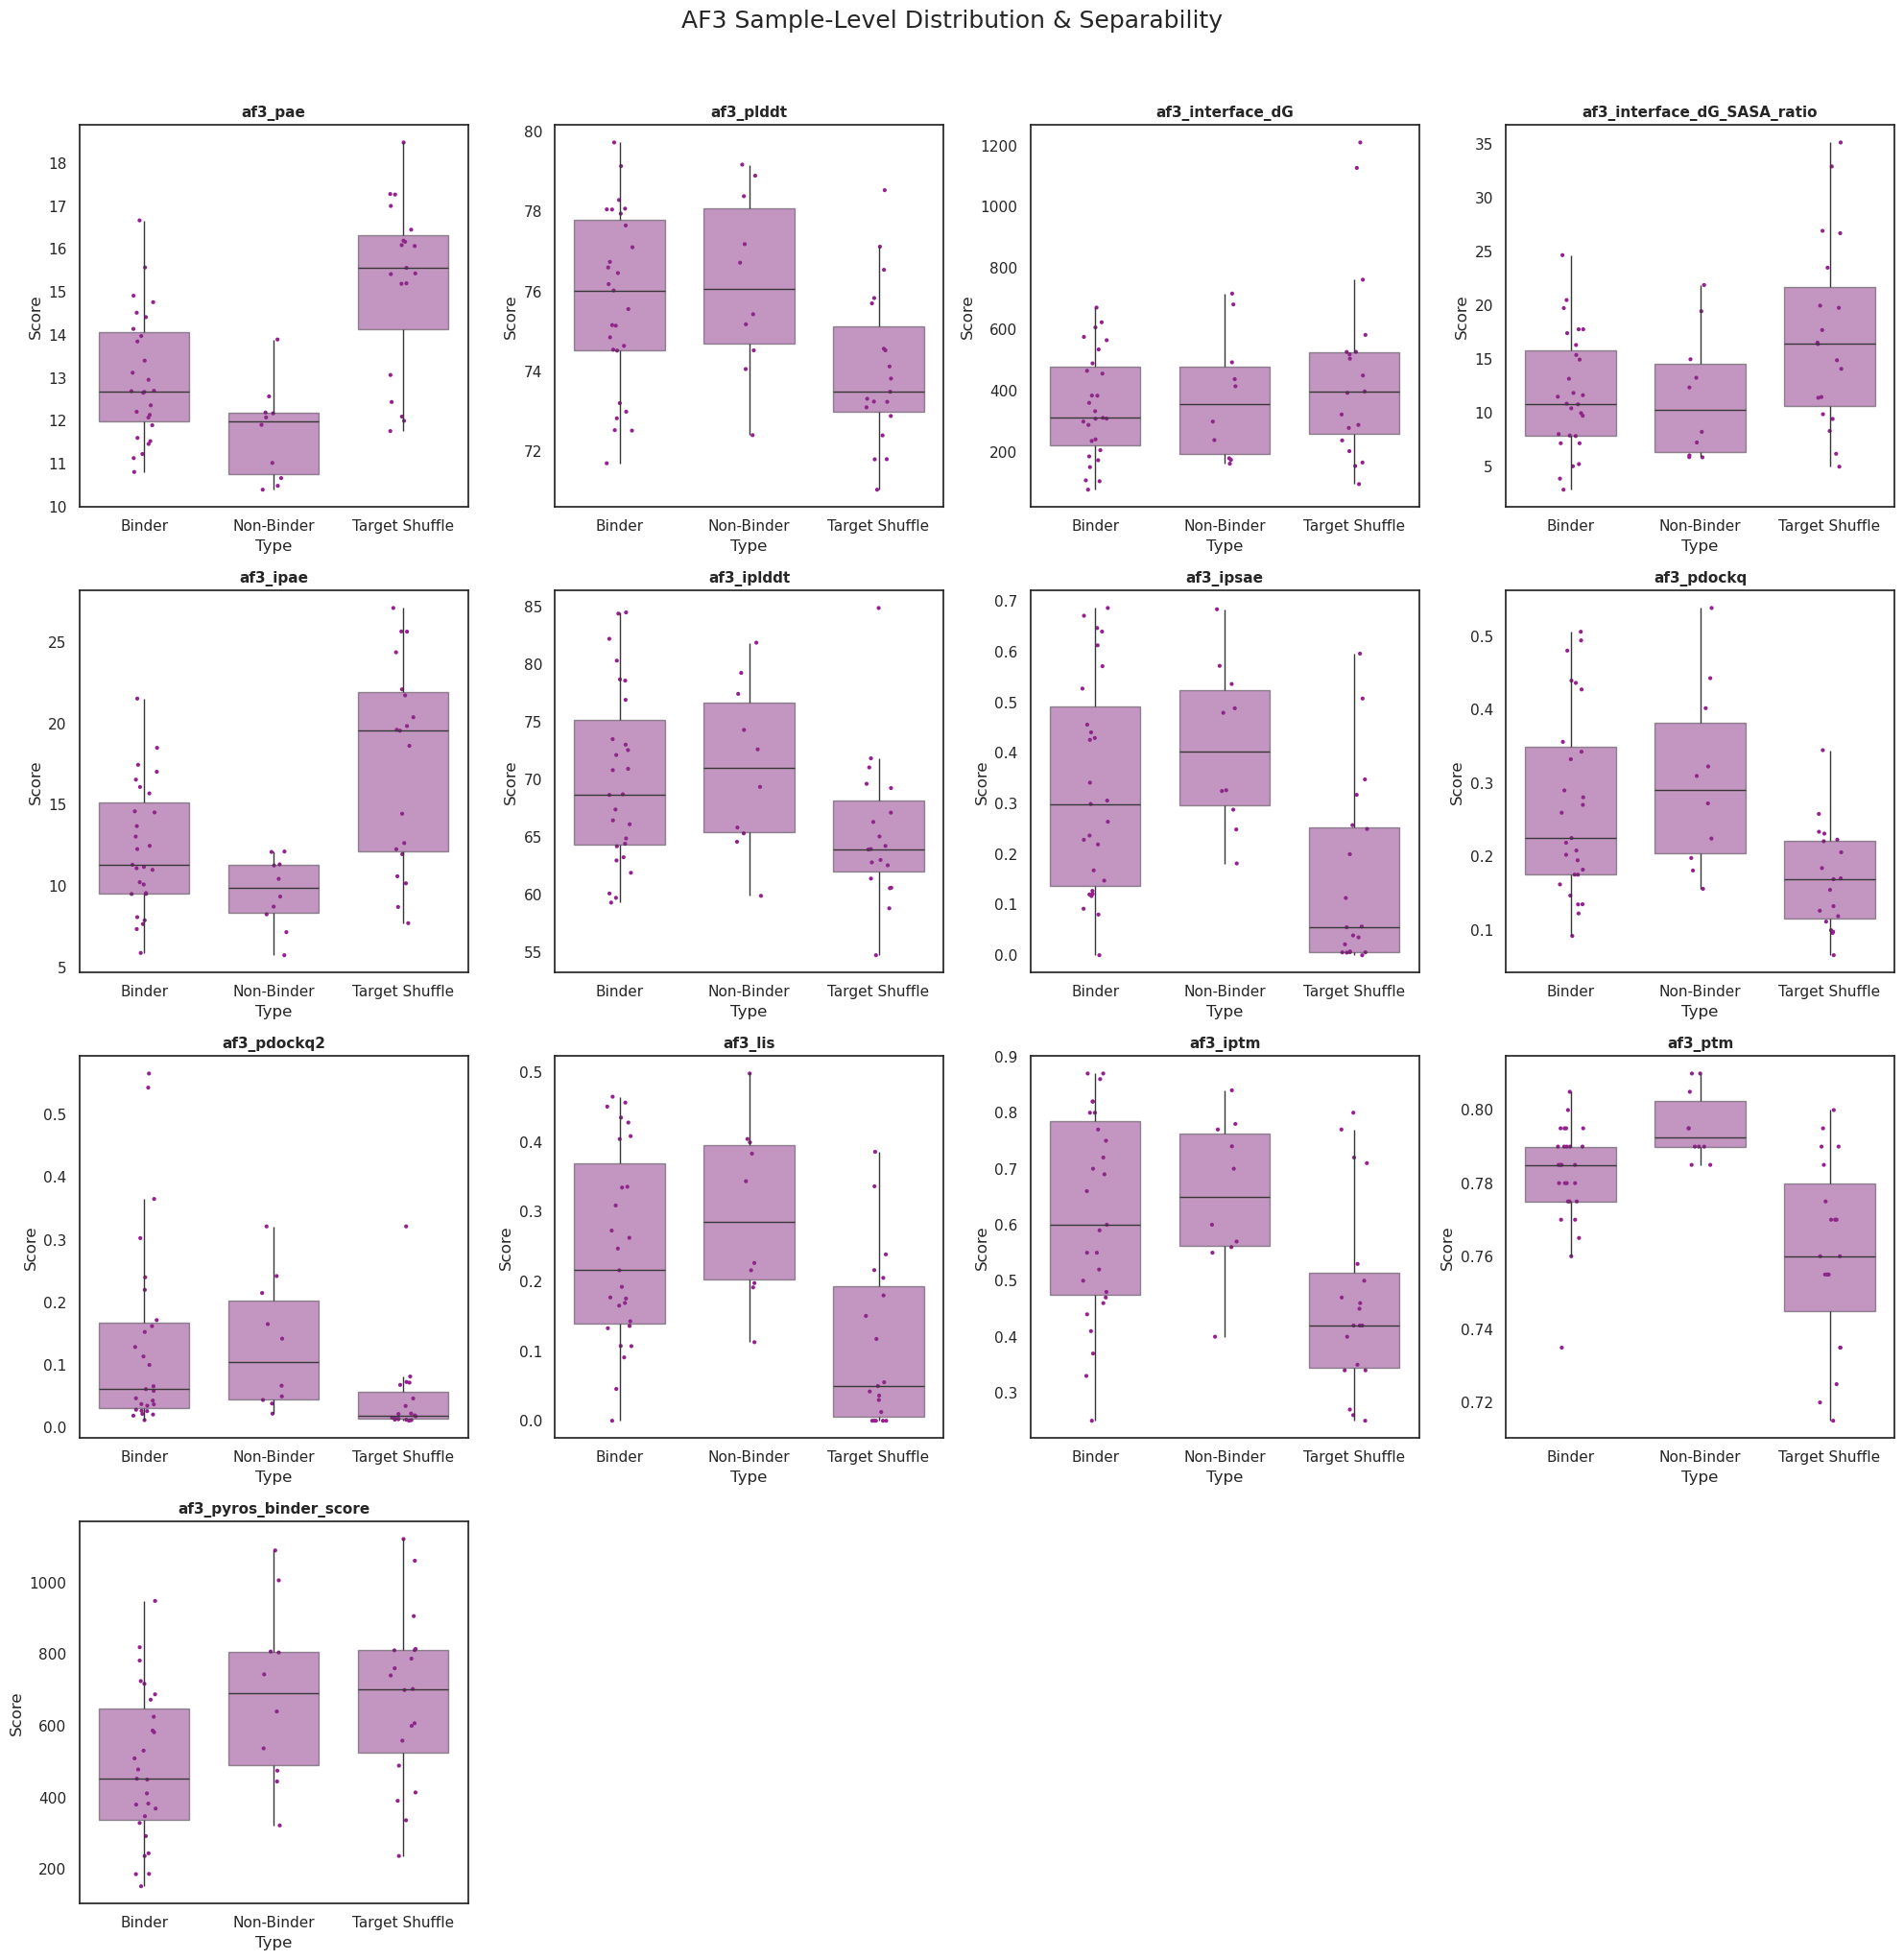

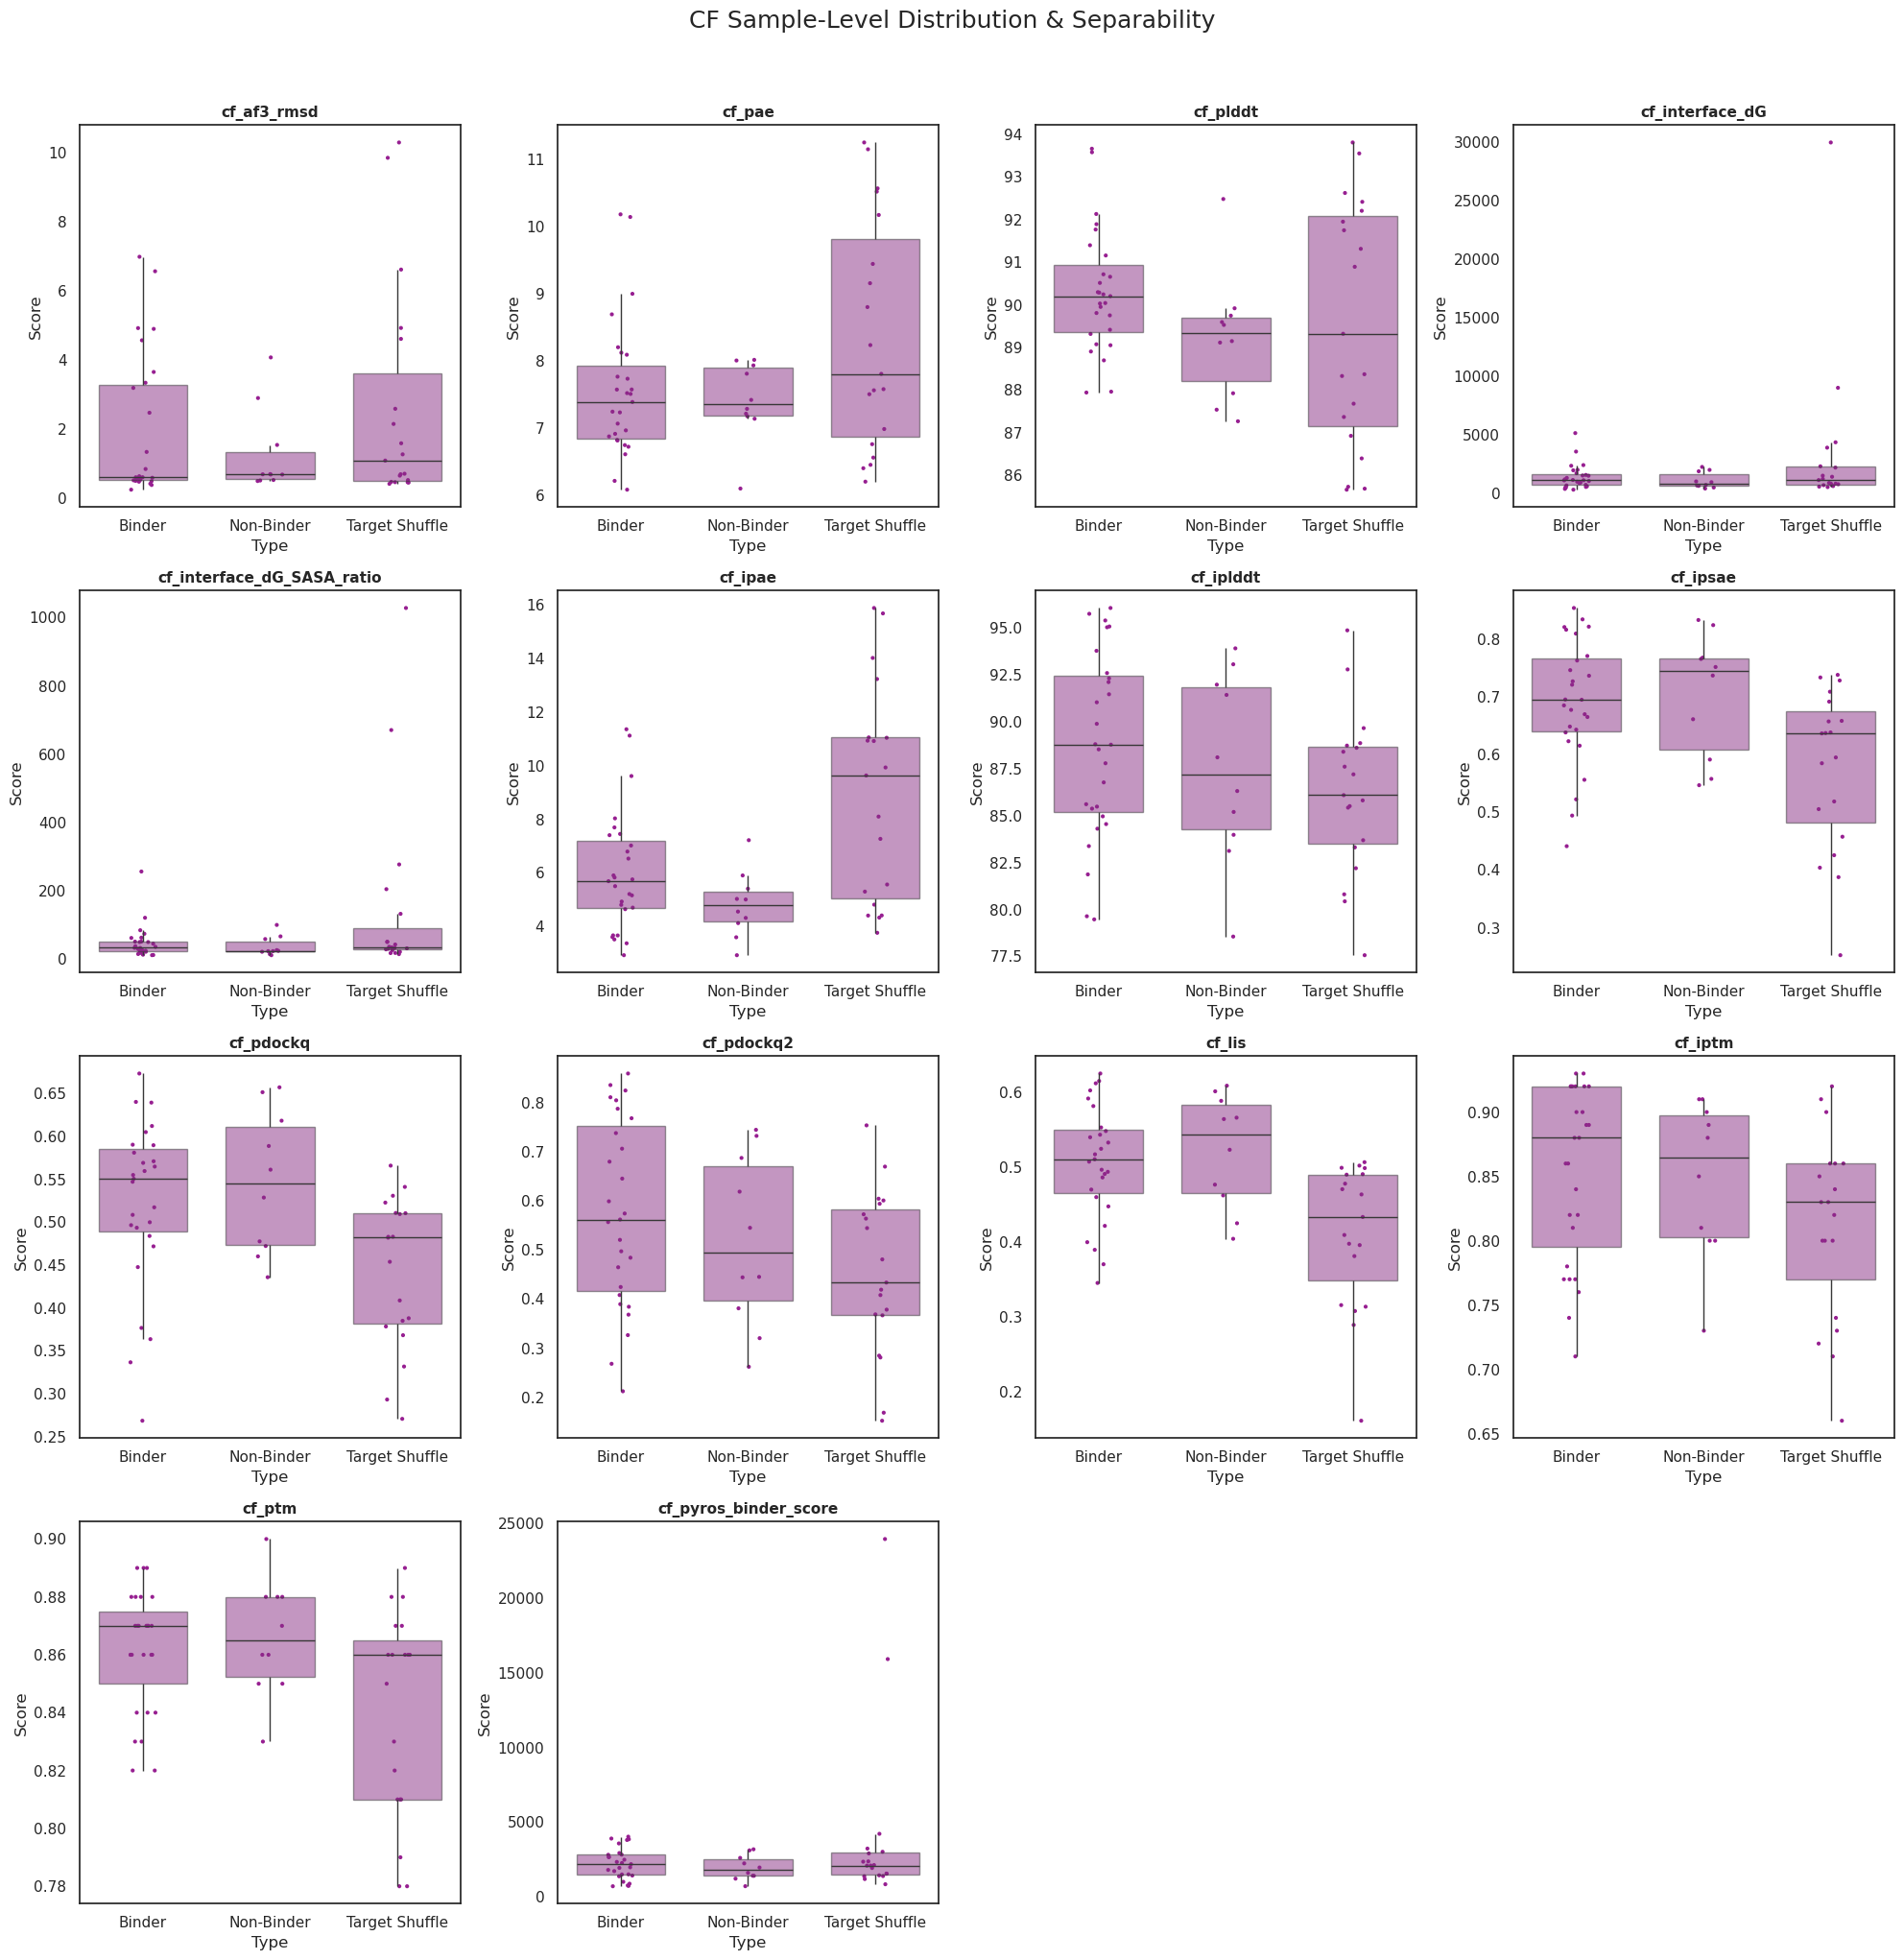

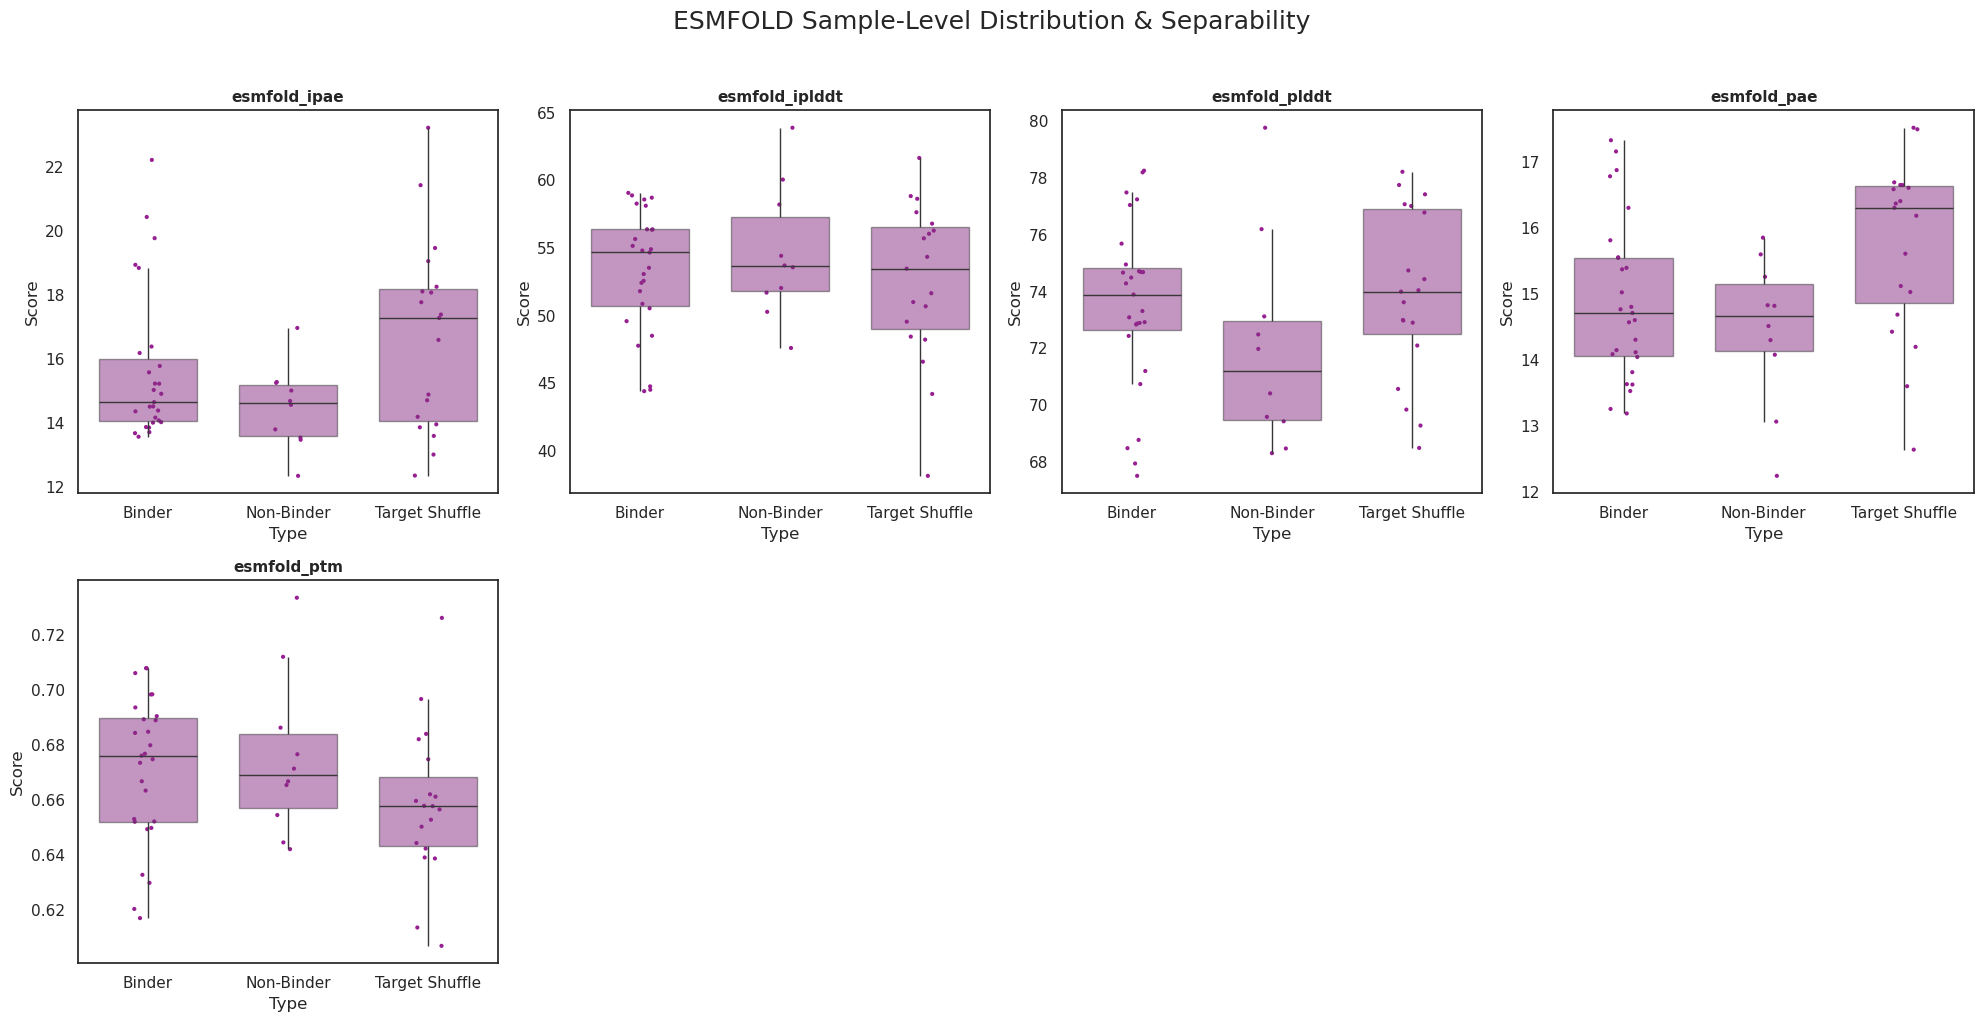

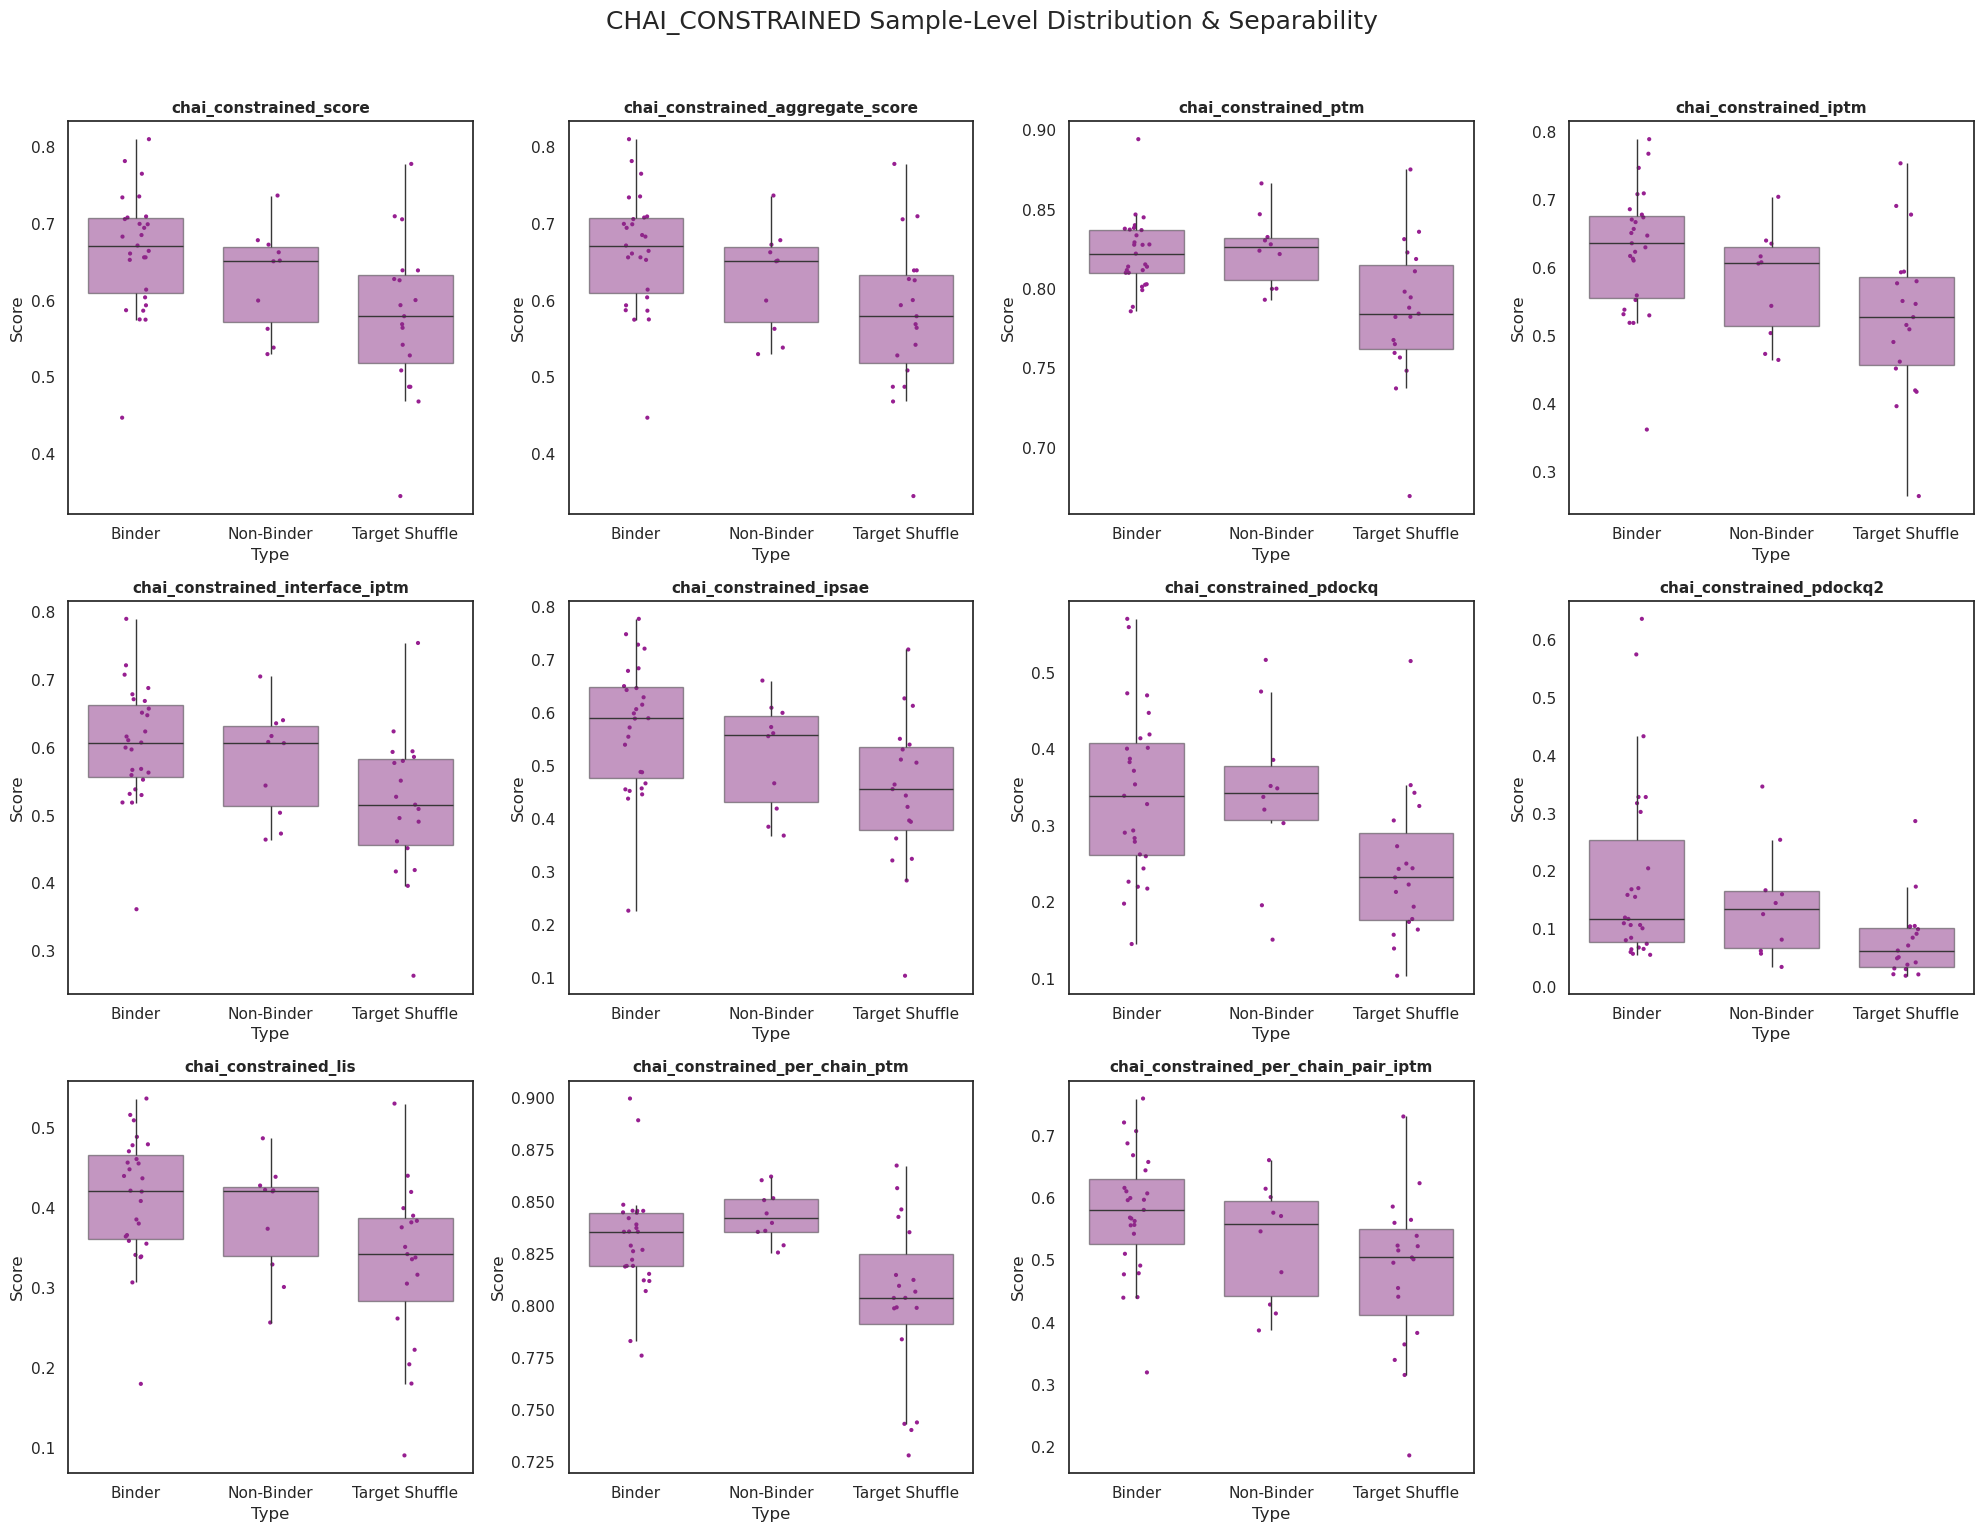

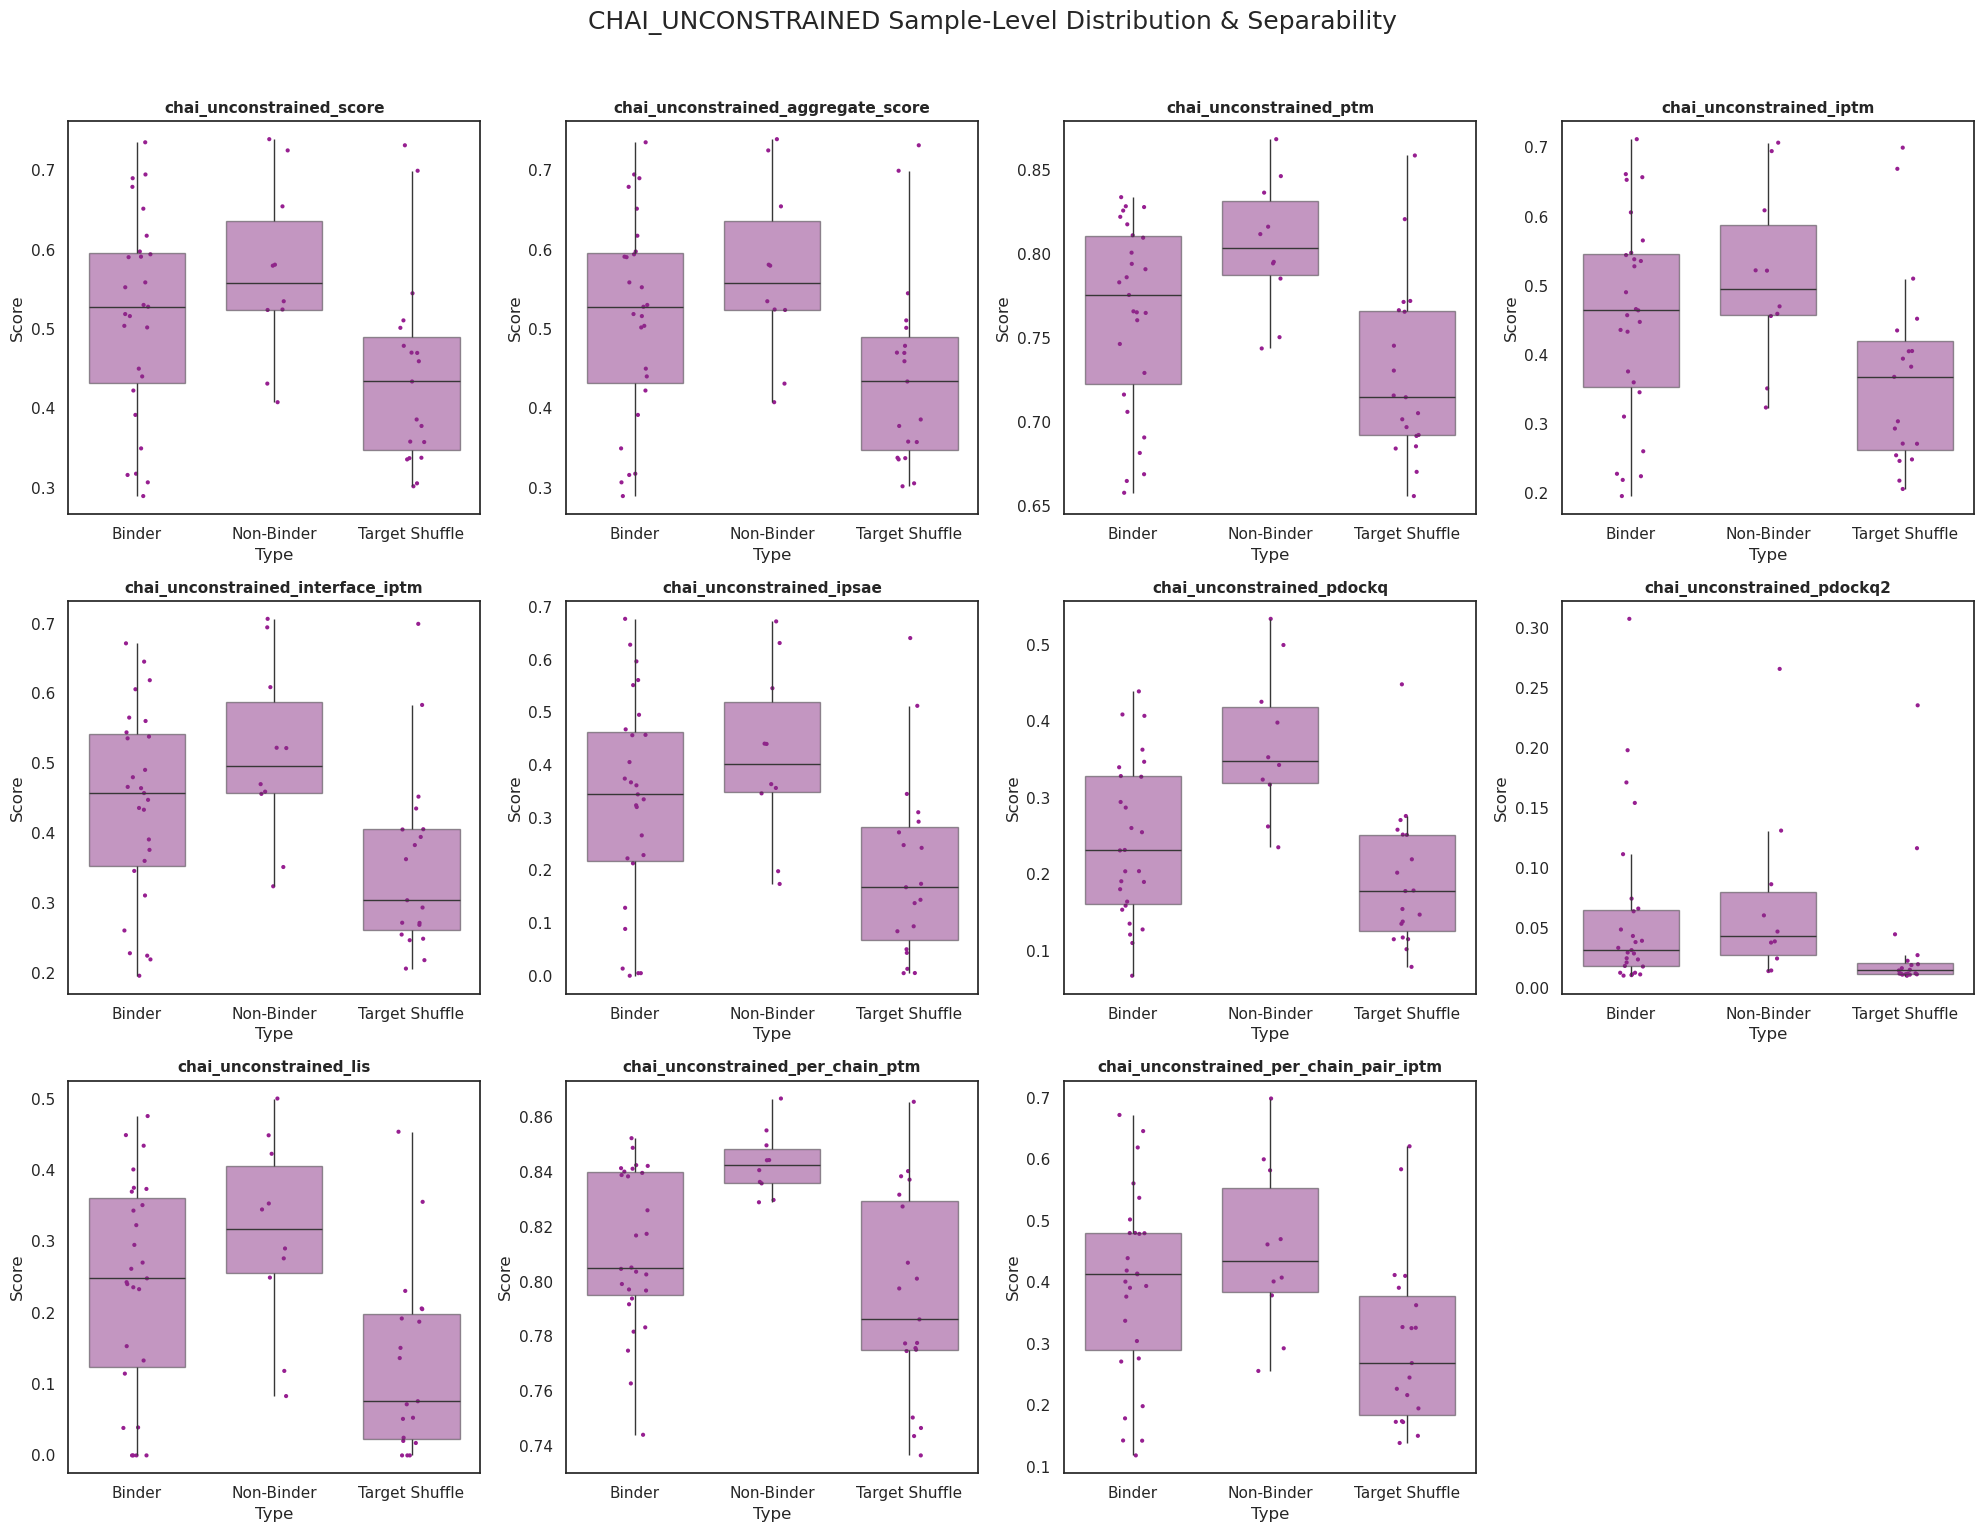

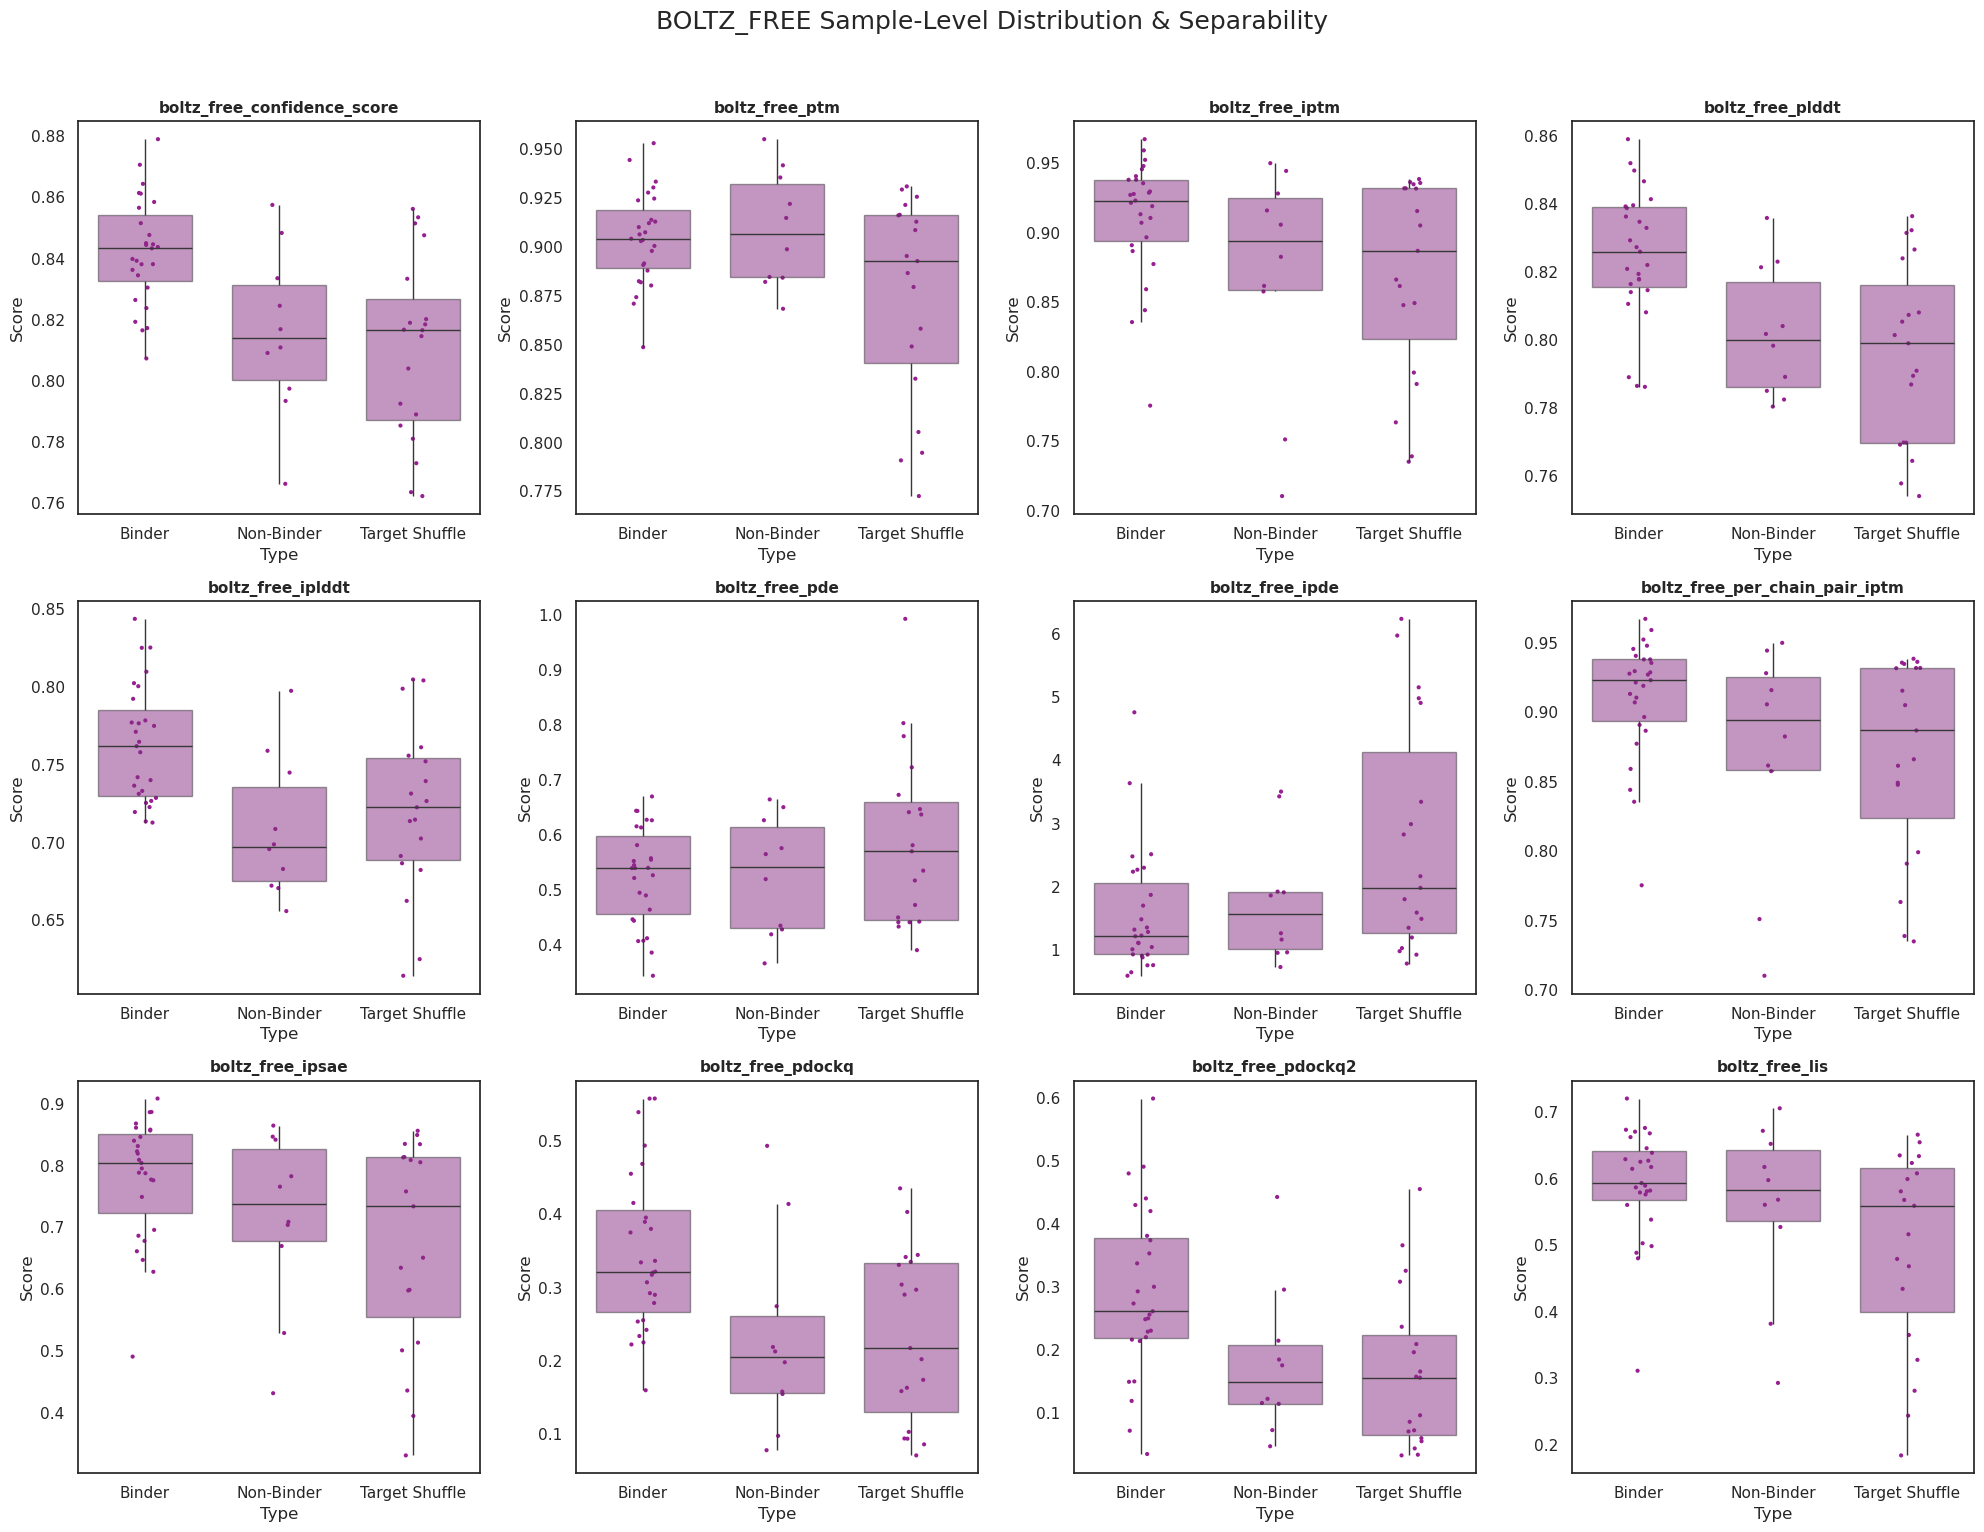

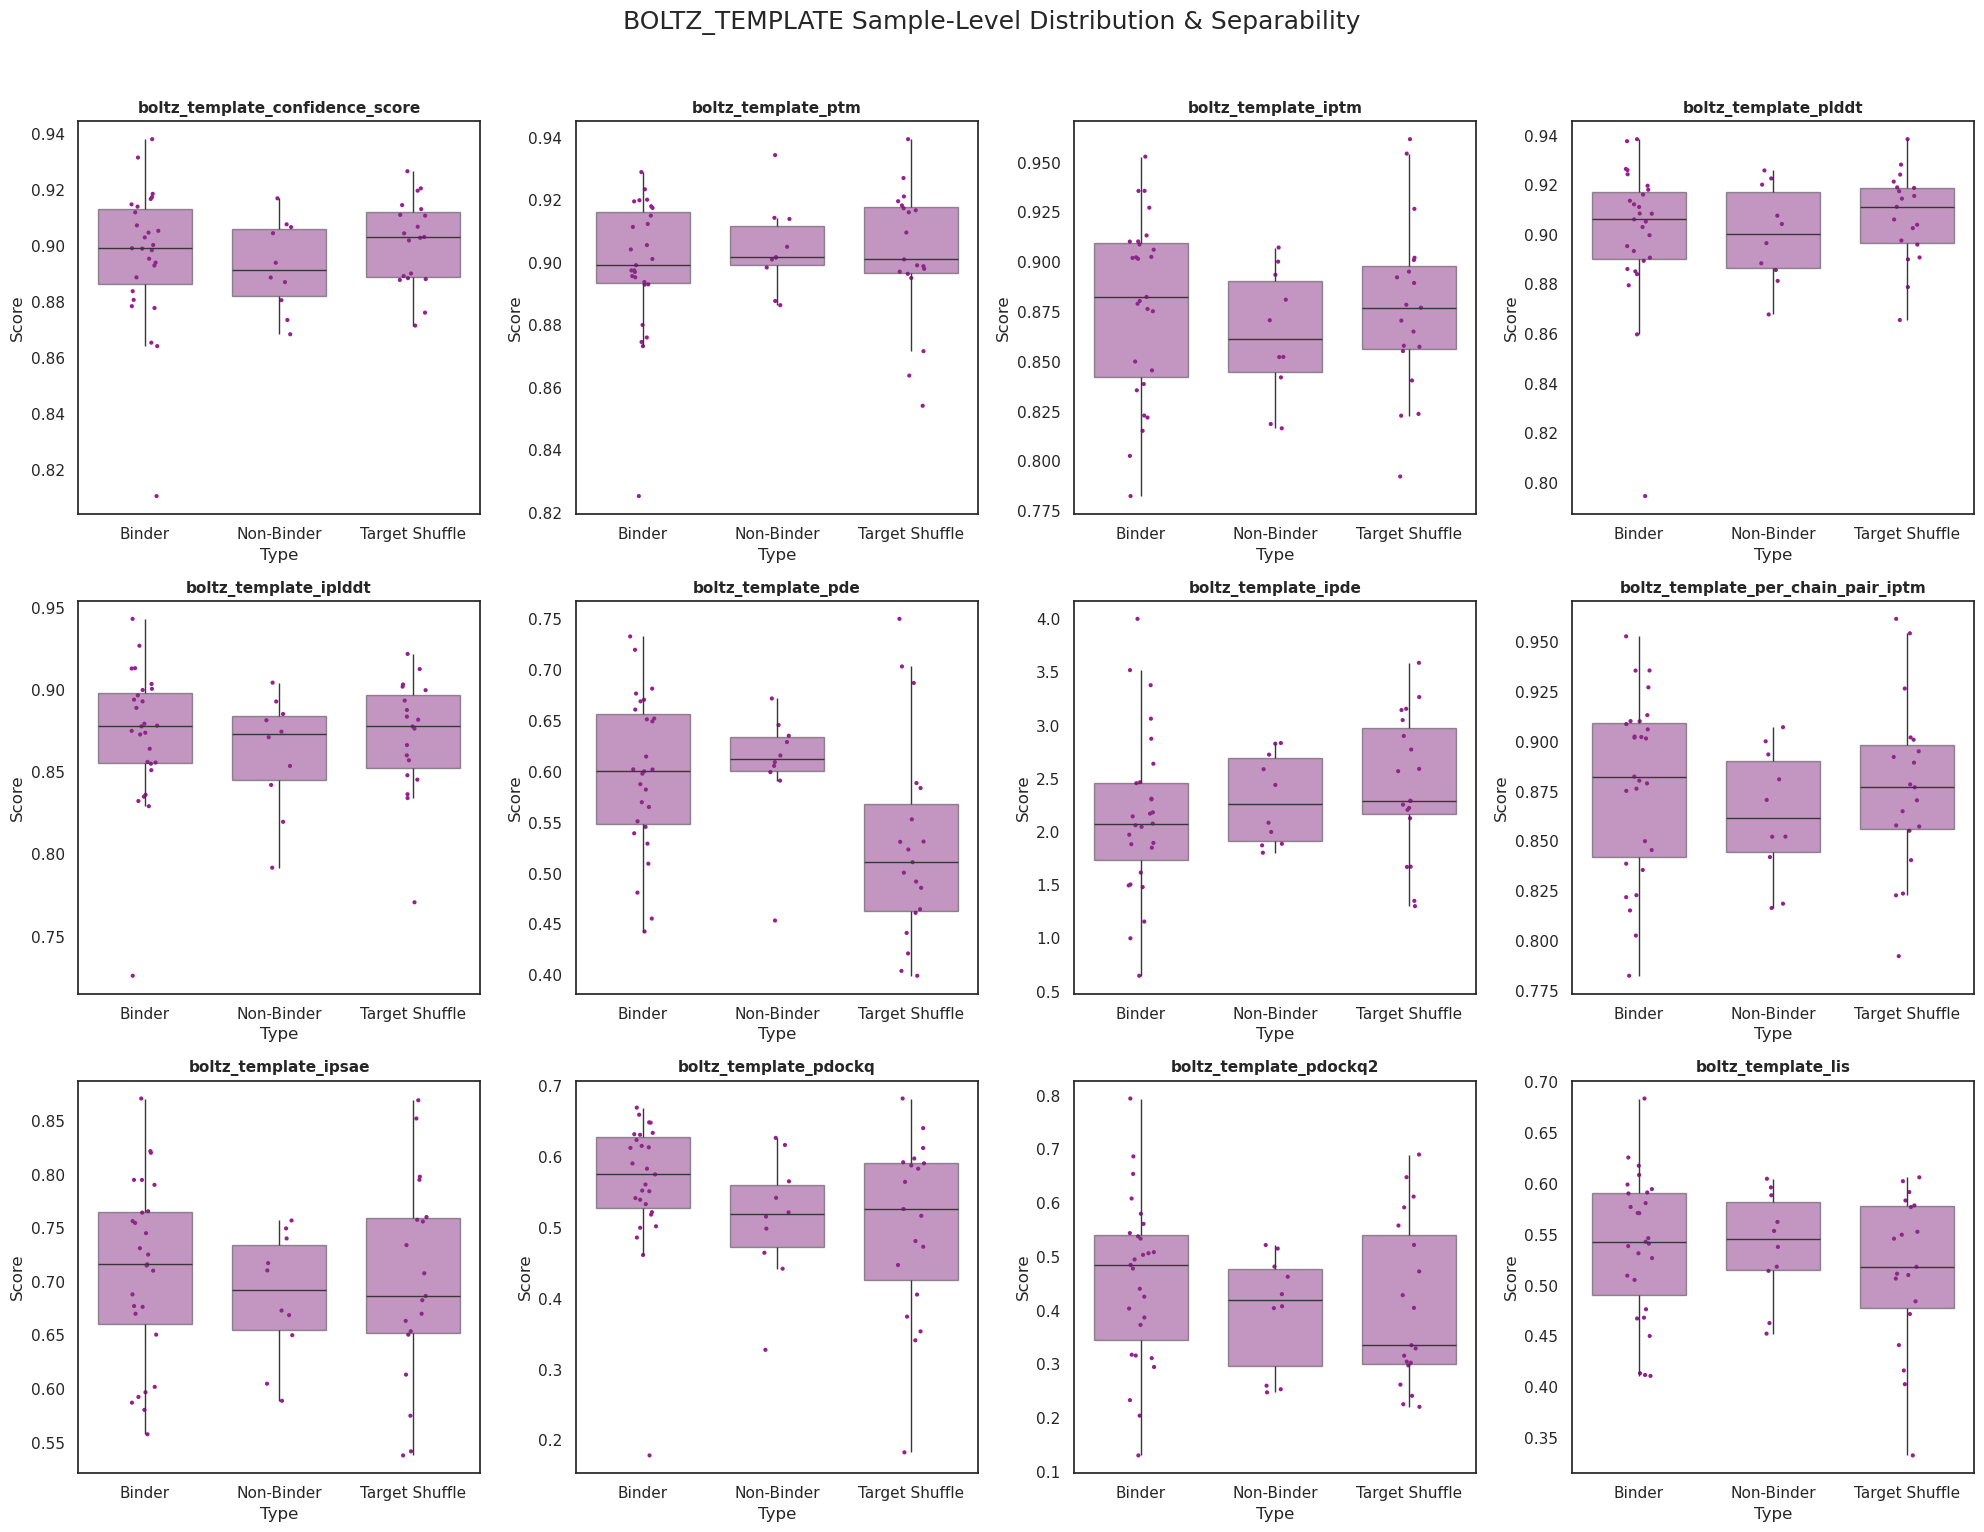

Finished generating scatterplots for BOLTZ_TEMPLATE group.


In [8]:
# Detailed Separability

import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetics
sns.set_theme(style="white")

# Determine if there are multiple classes to compare
has_both_classes = scores_df['binder'].nunique() > 1

for model, cols in model_groups.items():
    if not cols: continue
    
    # Filter out columns that are entirely NaN to prevent the "bxp length" error
    valid_cols = [c for c in cols if scores_df[c].notna().any()]
    if not valid_cols:
        print(f"Skipping {model.upper()}: No valid numeric data found.")
        continue


    # Calculate grid size
    n_cols = 4
    n_rows = (len(valid_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    
    for i, col in enumerate(valid_cols):
        ax = axes[i]
        
        # df contains 'binder_type'
        plot_df = scores_df.dropna(subset=[col]).copy()

        
        if plot_df.empty:
            continue

        hue_order = sorted(plot_df['source'].unique())
        #x_order = sorted(plot_df['binder'].unique())
        x_order = [
            "Binder",
            "Non-Binder",
            "Target Shuffle"
        ]

        # Stripplot
        sns.stripplot(
            data=plot_df, 
            x='binder_type', 
            y=col, 
            order=x_order,
            hue='source',
            hue_order=hue_order,
            dodge=True,
            jitter=0.1, 
            palette=colors_map,
            size=3,
            ax=ax,
            legend=False 
        )
        
        # Boxplot  ???
        sns.boxplot(
            data=plot_df, 
            x='binder_type', 
            y=col, 
            order=x_order,
            dodge=True,
            showcaps=False, 
            fill=True, 
            hue='source',
            hue_order=hue_order,
            palette=colors_map,
            ax=ax,
            width=0.7,
            zorder=10, 
            showfliers=False,
            legend=False 
        )

        for artist in ax.patches:
            artist.set_alpha(0.5)
        
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_xlabel('Type')
        ax.set_ylabel('Score')

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
        
    plt.suptitle(f"{model.upper()} Sample-Level Distribution & Separability", fontsize=18, y=1.02)
    plt.tight_layout()
    
    # Save output
    save_path = OUTPUT_DIR / f"{model}_separability_scatter.png"
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show() 
    
print(f"Finished generating scatterplots for {model.upper()} group.")

#### Correlation Matrix

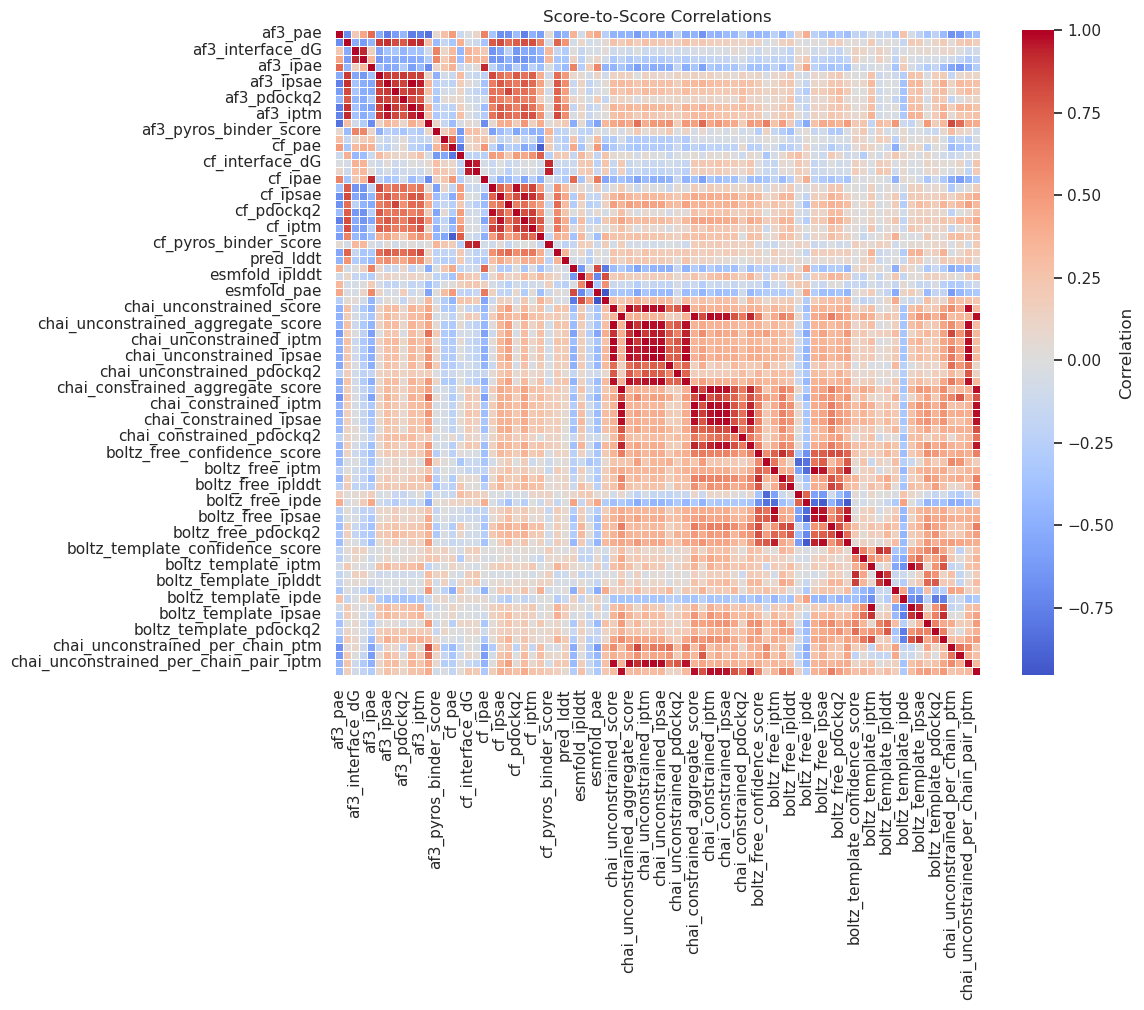

<Figure size 640x480 with 0 Axes>

In [9]:
# directions!!!!!
# Create numeric df and drop binder column
numeric_df = scores_df.select_dtypes(include=[np.number])
numeric_df = numeric_df.dropna(axis=1, how='all')
numeric_df = numeric_df.drop('binder', axis=1, errors='ignore')
numeric_df = numeric_df.drop('iteration', axis=1, errors='ignore')
numeric_df = numeric_df.drop('KD[M]', axis=1, errors='ignore')
numeric_df = numeric_df.drop('EC50[M]', axis=1, errors='ignore')

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Score-to-Score Correlations')
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / 'score_correlation_heatmap.png', dpi=500, bbox_inches='tight')


## identify outliers

In [10]:
numeric_df = scores_df.select_dtypes(include=["number"])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
outlier_counts = outliers.sum()
outlier_counts.sort_values(ascending=False)

pred_ilddt                                14
chai_unconstrained_pdockq2                 9
cf_interface_dG_SASA_ratio                 8
cf_pae                                     7
chai_constrained_pdockq2                   6
                                          ..
boltz_template_ipsae                       0
boltz_template_lis                         0
boltz_template_pdockq2                     0
chai_unconstrained_per_chain_ptm           0
chai_unconstrained_per_chain_pair_iptm     0
Length: 82, dtype: int64

In [11]:
z_scores = (numeric_df - numeric_df.mean()) / numeric_df.std()
outliers = z_scores.abs() > 3
outlier_counts = outliers.sum()
outlier_counts.sort_values(ascending=False)

af3_pdockq2                               2
af3_interface_dG                          2
cf_af3_rmsd                               2
chai_unconstrained_pdockq2                2
cf_pyros_binder_score                     2
                                         ..
boltz_template_ipsae                      0
boltz_template_lis                        0
chai_unconstrained_per_chain_ptm          0
chai_constrained_per_chain_ptm            0
chai_unconstrained_per_chain_pair_iptm    0
Length: 82, dtype: int64

In [12]:
def robust_outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))

In [13]:
median = numeric_df.median()
mad = (numeric_df - median).abs().median()

robust_z = (numeric_df - median) / mad
outliers = robust_z.abs() > 3.5

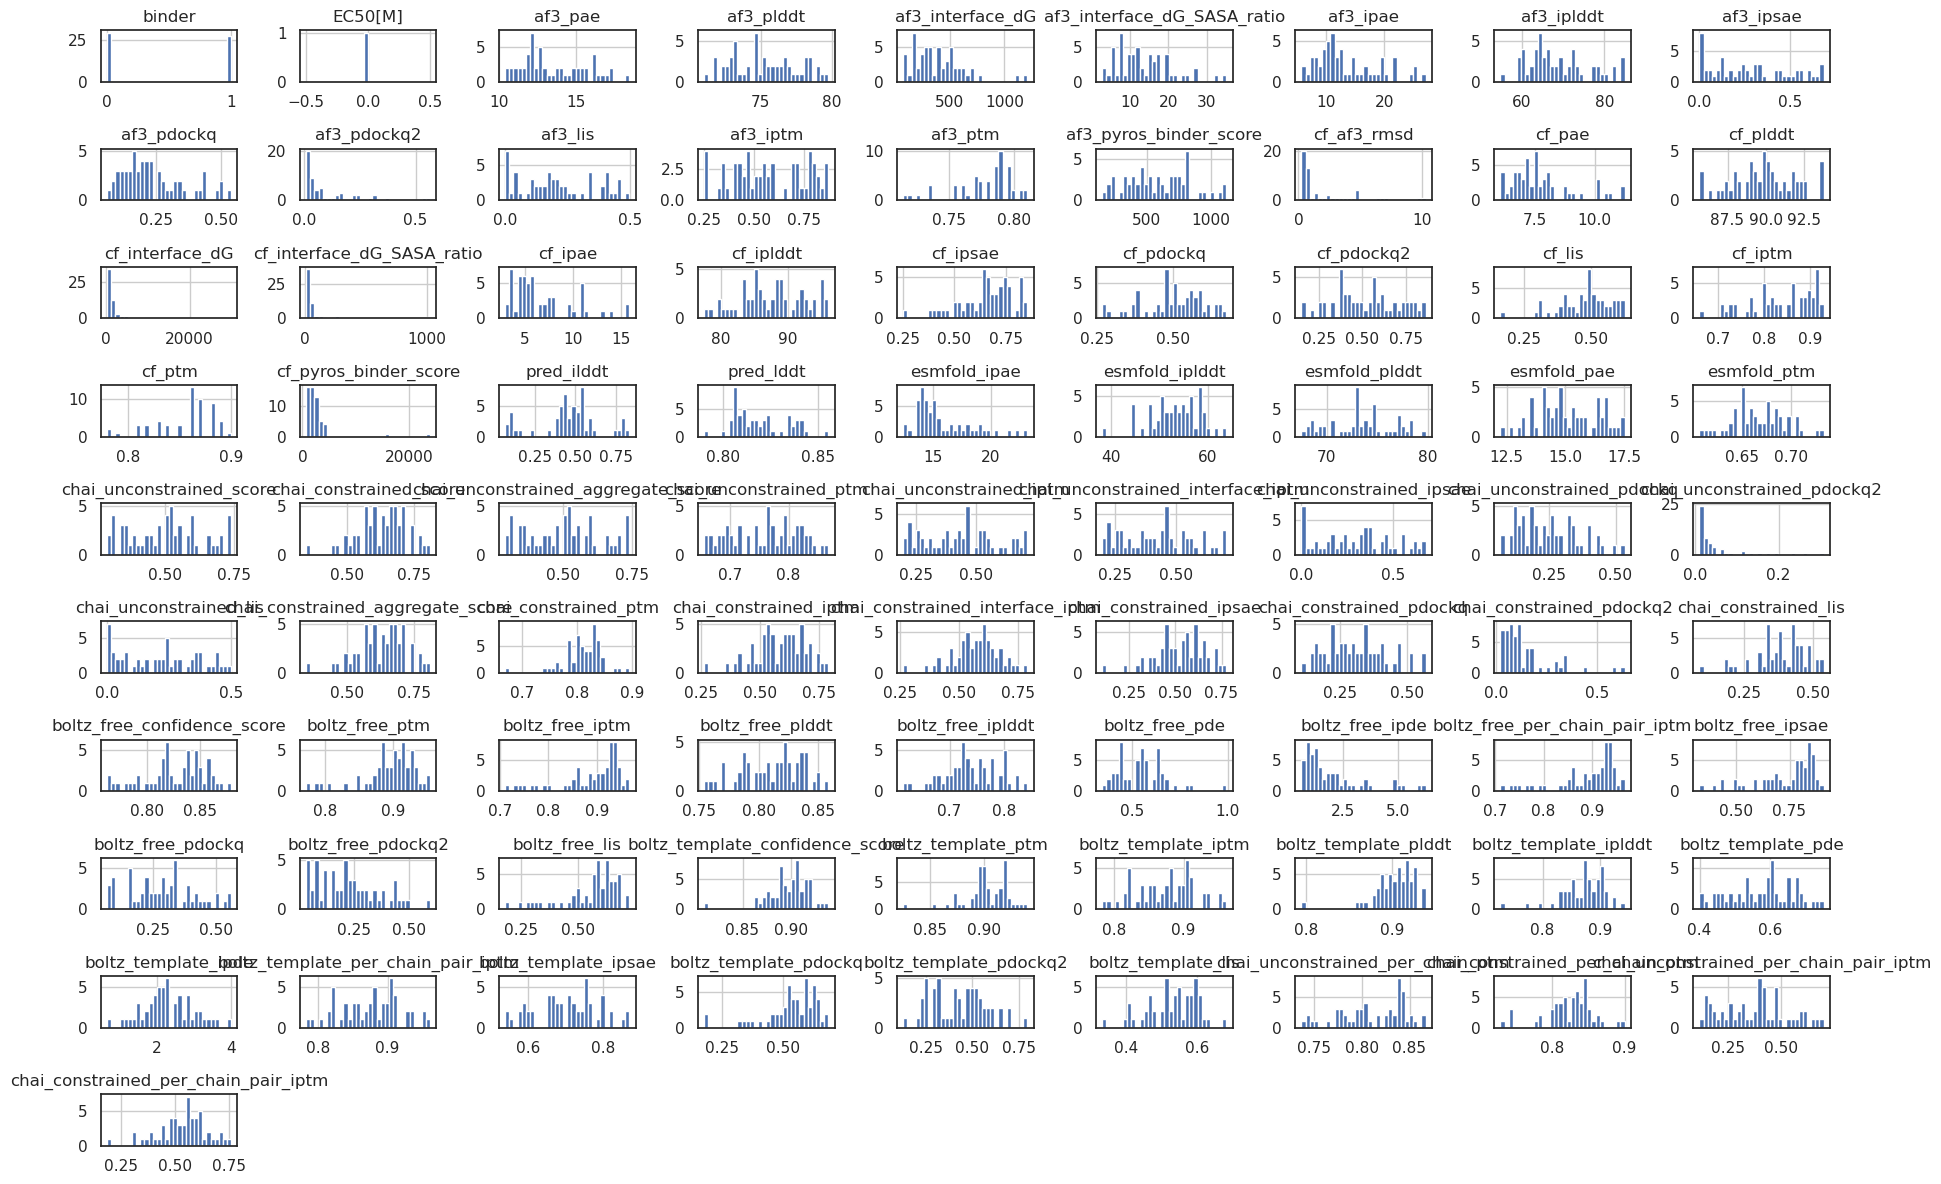

In [14]:
import matplotlib.pyplot as plt

numeric_df = scores_df.select_dtypes(include=["number"])

numeric_df.hist(figsize=(18, 12), bins=30)
plt.tight_layout()
plt.show()

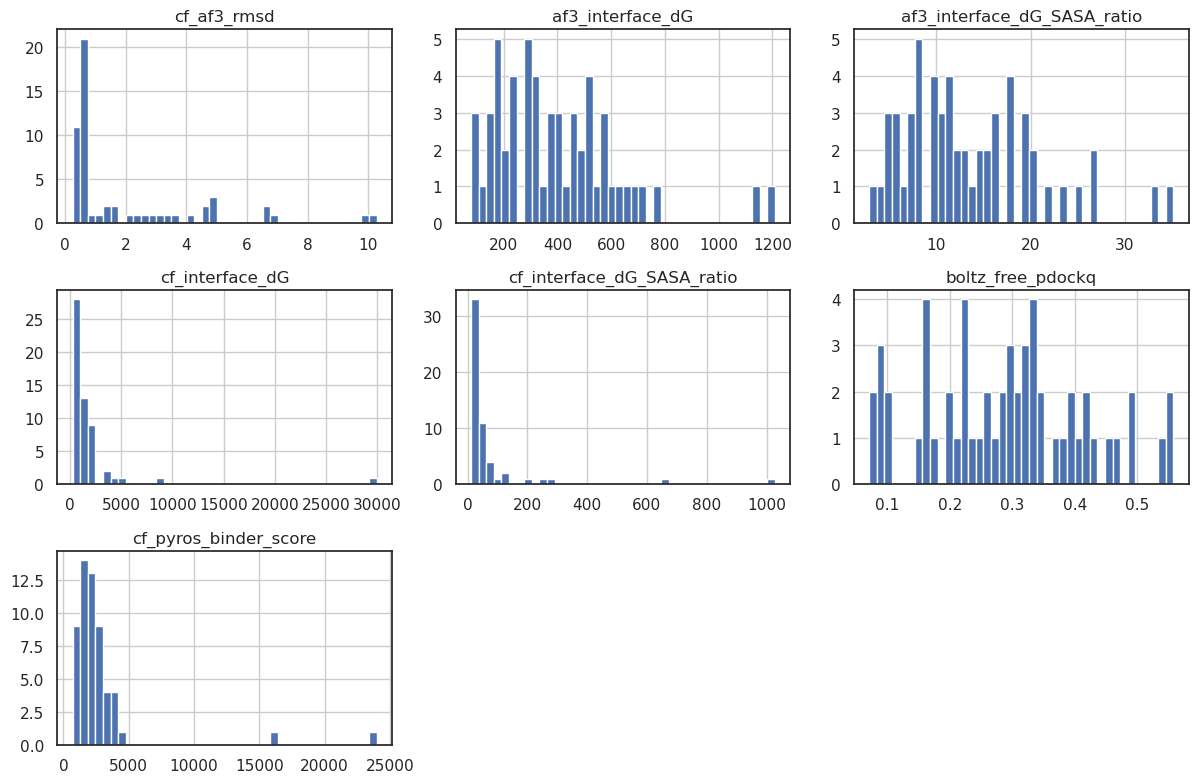

In [15]:
cols = [
    "cf_af3_rmsd",
    "af3_interface_dG",
    "af3_interface_dG_SASA_ratio",
    "cf_interface_dG",
    "cf_interface_dG_SASA_ratio",
    "boltz_free_pdockq",
    "cf_pyros_binder_score"
]

scores_df[cols].hist(bins=40, figsize=(12, 8))
plt.tight_layout()
plt.show()

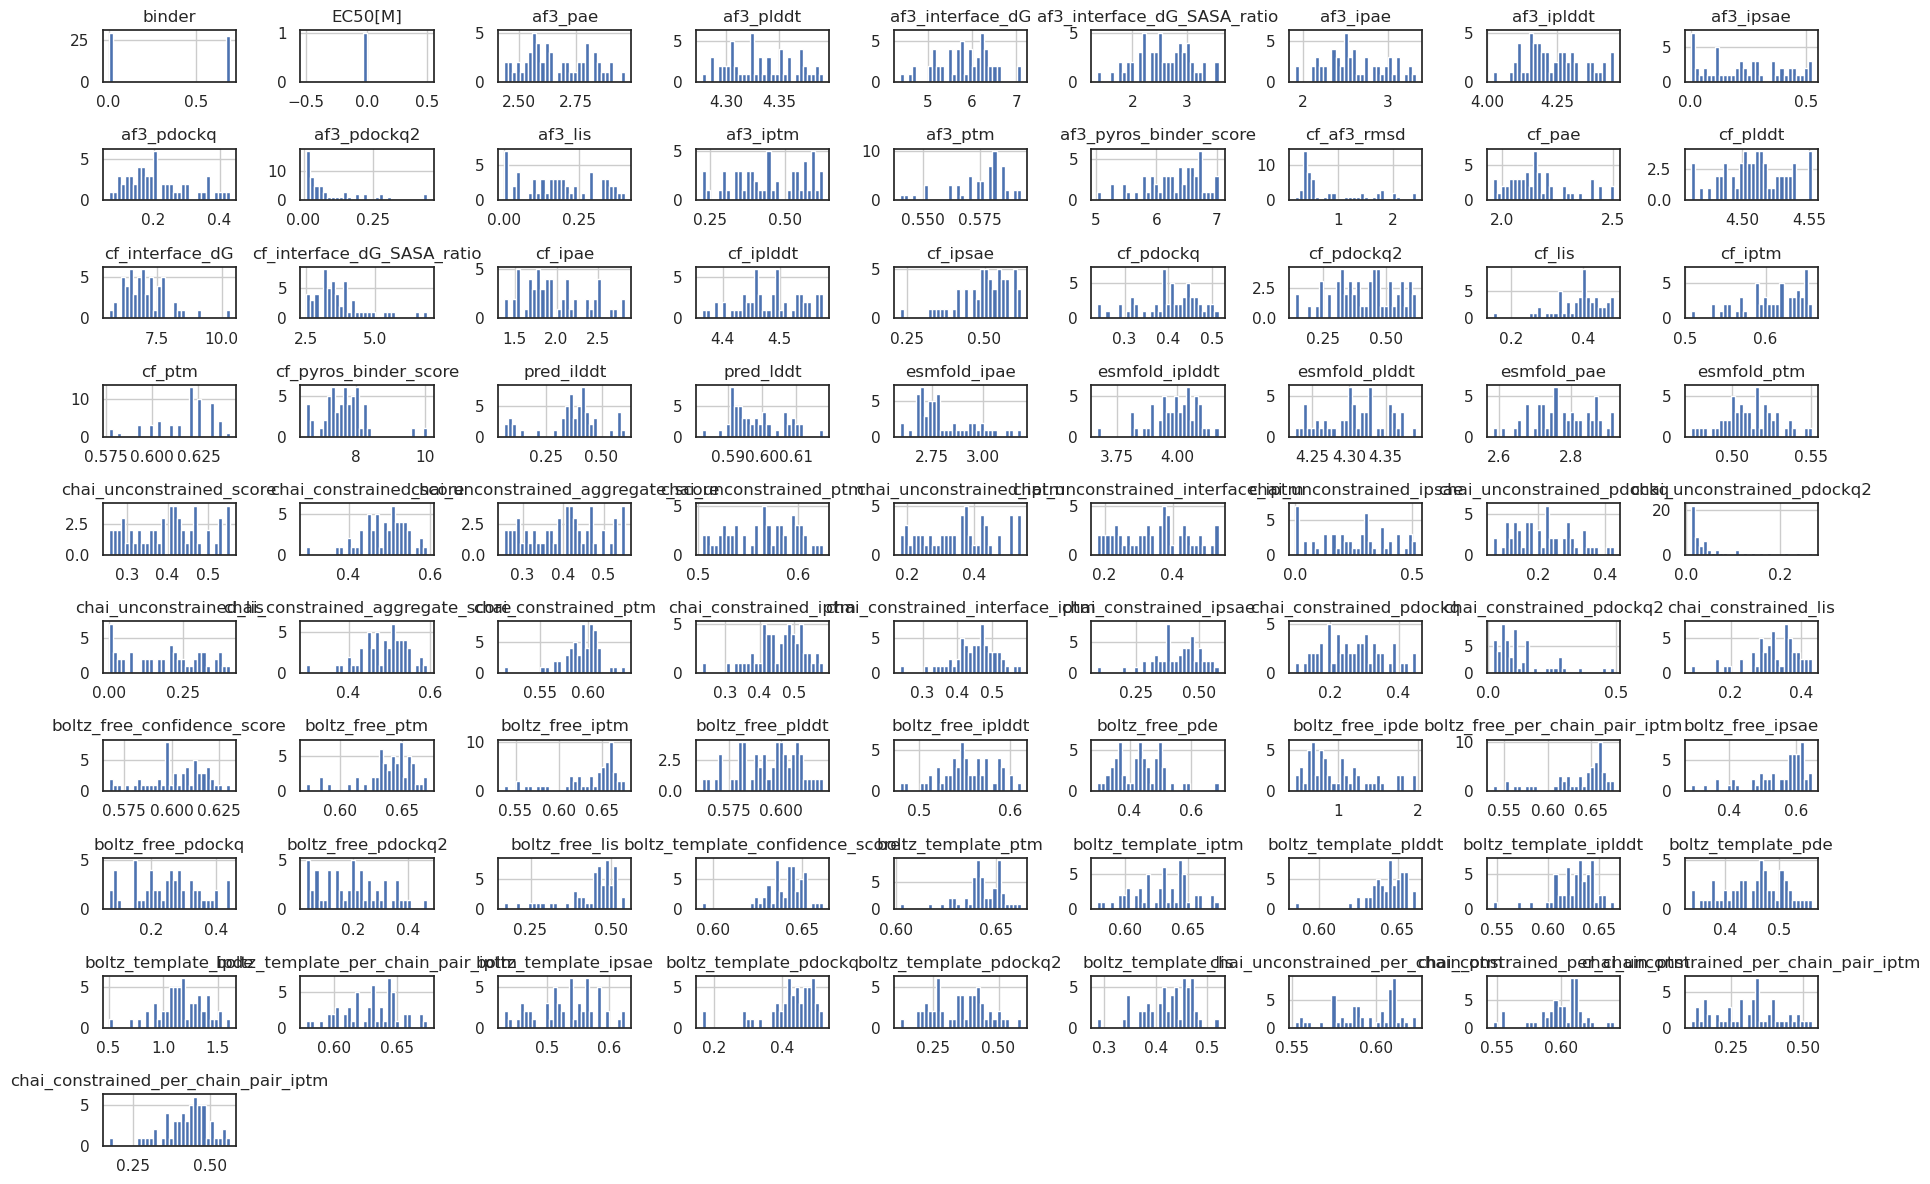

In [16]:
import numpy as np

log_df = np.log1p(numeric_df.clip(lower=0))
log_df.hist(figsize=(18, 12), bins=30)
plt.tight_layout()
plt.show()

In [17]:
df = scores_df.copy()
num = df.select_dtypes(include=["number"])

In [18]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
num_scaled = pd.DataFrame(
    scaler.fit_transform(num),
    columns=num.columns,
    index=num.index
)

In [19]:
good_cols = [
    "af3_plddt",
    "af3_ptm",
    "cf_plddt",
    "boltz_free_ptm",
    "af3_pdockq",
    "cf_pdockq",
    "boltz_free_pdockq"
]

bad_cols = [
    "af3_interface_dG",
    "cf_interface_dG",
    "af3_ipae",
    "cf_ipae"
]

score = pd.Series(0, index=num.index)

# good metrics contribute positively
score += num_scaled[good_cols].mean(axis=1)

# bad metrics subtract (invert)
score -= num_scaled[bad_cols].mean(axis=1)

In [20]:
threshold = score.median()  # or top 30%

labels = (score > threshold).astype(int)
df["prediction_quality"] = labels

In [21]:
df.groupby("prediction_quality")[good_cols + bad_cols].mean()

,af3_plddt,af3_ptm,cf_plddt,boltz_free_ptm,af3_pdockq,cf_pdockq,boltz_free_pdockq,af3_interface_dG,cf_interface_dG,af3_ipae,cf_ipae
prediction_quality,,,,,,,,,,,
0,73.970987,0.766607,89.341765,0.880889,0.165811,0.430450,0.231961,456.362500,2871.903214,16.834133,8.391917
1,76.565872,0.788214,90.396997,0.909558,0.319014,0.568857,0.345282,329.745714,1063.695357,10.436744,5.196573


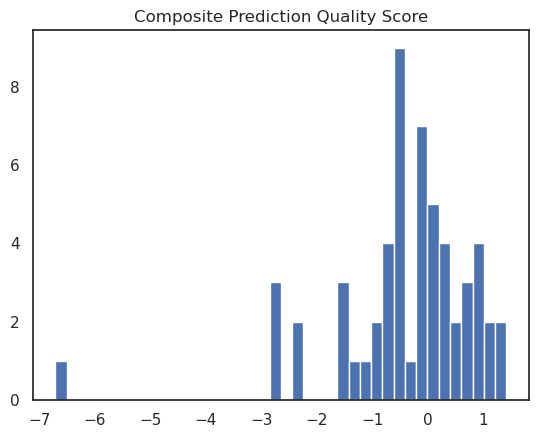

In [22]:
import matplotlib.pyplot as plt

plt.hist(score, bins=40)
plt.title("Composite Prediction Quality Score")
plt.show()